Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Epoch 1/100

Epoch 1: val_loss improved from inf to 4.61672, saving model to checkpoint_best_stanford_dogs.h5
1029/1029 - 146s - loss: 6.7088 - accuracy: 0.0152 - val_loss: 4.6167 - val_accuracy: 0.0379 - 146s/epoch - 142ms/step
Epoch 2/100

Epoch 2: val_loss improved from 4.61672 to 4.43008, saving model to checkpoint_best_stanford_dogs.h5
1029/1029 - 117s - loss: 4.9971 - accuracy: 0.0212 - val_loss: 4.4301 - val_accuracy: 0.0819 - 117s/epoch - 114ms/step
Epoch 3/100

Epoch 3: val_loss improved from 4.43008 to 4.27822, saving model to checkpoint_best_stanford_dogs.h5
1029/1029 - 117s - loss: 4.7027 - accuracy: 0.0347 - val_loss: 4.2782 - val_accuracy: 0.1431 - 117s/epoch - 114ms/step
Epoch 4/100

Epoch 4: val_loss improved from 4.27822 to 4.04561, saving model to checkpoint_best_stanford_dogs.h5
1029/1029 - 117s - loss: 4.5153 - accu

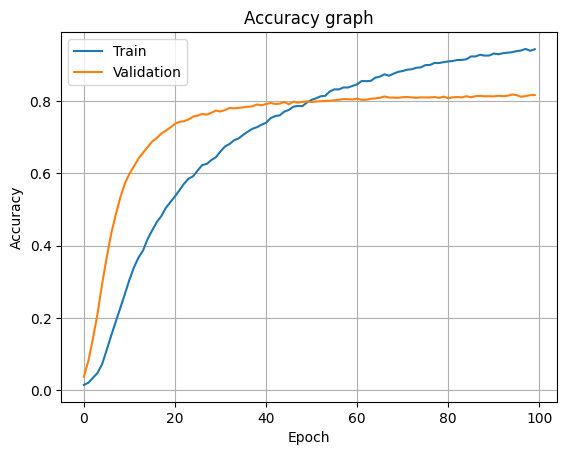

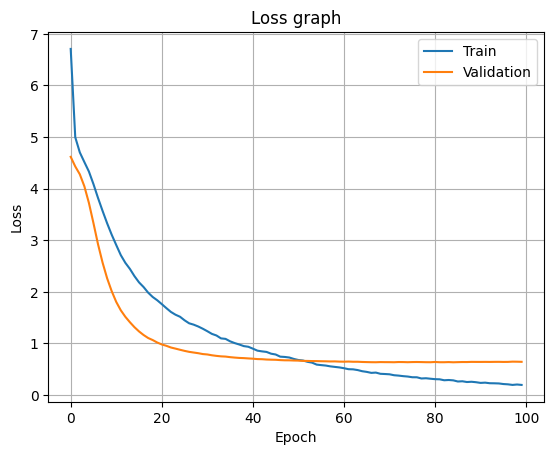

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Rescaling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint
import pathlib
import time
import pickle
import matplotlib.pyplot as plt

# [1] 데이터 경로 지정
data_path = pathlib.Path('datasets/images')

# [2] 학습 데이터 & 검증 데이터셋 생성
train_ds = image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=16
)

test_ds = image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    batch_size=16
)

# [3] DenseNet121 사전 학습 모델 (가중치 다운로드는 처음 1회만 필요)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# [4] 모델 구조 정의
cnn = Sequential()
cnn.add(Rescaling(1.0 / 255.0))
cnn.add(base_model)
cnn.add(Flatten())
cnn.add(Dense(1024, activation='relu'))
cnn.add(Dropout(0.75))
cnn.add(Dense(units=120, activation='softmax'))  # Stanford Dogs: 120종

# [5] 모델 컴파일
cnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.000001),
    metrics=['accuracy']
)

# [6] 체크포인트 콜백 (val_loss가 가장 낮은 가중치만 저장)
checkpoint_cb = ModelCheckpoint(
    filepath='checkpoint_best_stanford_dogs.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# [7] 학습 시작 시간 측정
start_time = time.time()

# [8] 모델 학습
hist = cnn.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[checkpoint_cb],
    verbose=2
)

# [9] 학습 종료 후 시간 계산
elapsed_time = time.time() - start_time
print(f'전체 학습 시간: {elapsed_time / 60:.2f} 분')

# [10] 최종 평가 (참고: checkpoint_best로 다시 불러서 평가해도 됨)
final_acc = cnn.evaluate(test_ds, verbose=0)[1] * 100
print('최종 정확률 =', final_acc)

# [11] 학습된 최종 모델 저장
cnn.save('cnn_for_stanford_dogs.h5')

# [12] 클래스 이름 저장 (라벨 인덱스와 매칭)
with open('dog_species_names.txt', 'wb') as f:
    pickle.dump(train_ds.class_names, f)

# [13] Accuracy 그래프
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Accuracy graph')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

# [14] Loss 그래프
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Loss graph')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()


In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.10.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
